In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import joblib

Loading the data

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#Checking the shape
df.shape

(284807, 31)

In [4]:
#Checking the datatypes and null/non-null distribution
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
#Checking distribution of numerical values in dataset
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Data Cleaning

In [6]:
df.duplicated().any()

np.True_

In [7]:
df = df.drop_duplicates()
df.shape

(283726, 31)

In [8]:
df.to_csv("cleaned_fraud_data.csv", index=False)

In [9]:
# Scaling the amount feature
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

Exploratory data analysis

In [10]:
#Checking class distribution
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [11]:
#Percentage distribution  of normal vs fraud
classes= df['Class'].value_counts()
normal= classes[0]/df['Class'].count()*100
fraud= classes[1]/df['Class'].count()*100
print(normal)
print(fraud)

99.83328986416473
0.1667101358352777


In [18]:
scaler = StandardScaler()
df[['scaled_amount','scaled_time']] = scaler.fit_transform(df[['Amount','Time']])
df = df.drop(['Amount','Time'], axis=1)

In [19]:
y= df['Class']
x= df.drop(['Class'], axis=1)

In [20]:
x.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,-1.996823
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,-1.996823
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,-1.996802
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,-1.996802
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,-1.996781


In [21]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

On original imbalanced data

In [22]:
#Splitting data into train and test data
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2, stratify=y)

Model Training

In [23]:
classifier = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
     "Decision Tree": DecisionTreeClassifier(random_state= 42),
     "Random Forest": RandomForestClassifier(random_state= 42)
}
for name, clf in classifier.items():
    print(f"\n========{name}=========")
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    y_probs = clf.predict_proba(x_test)[:, 1]
    print(f"\n Accuracy: {accuracy_score(y_test,y_pred)}")
    print(f"\n Precision: {precision_score(y_test,y_pred)}")
    print(f"\n Recall: {recall_score(y_test,y_pred)}")
    print(f"\n F1_Score: {f1_score(y_test,y_pred)}")
    print(f"ROC-AUC: {roc_auc_score(y_test, y_probs)}")


========Logistic Regression=========

 Accuracy: 0.9991365030134283

 Precision: 0.8484848484848485

 Recall: 0.5894736842105263

 F1_Score: 0.6956521739130435
ROC-AUC: 0.9583739405352626

========Decision Tree=========

 Accuracy: 0.9990307686885419

 Precision: 0.7127659574468085

 Recall: 0.7052631578947368

 F1_Score: 0.708994708994709
ROC-AUC: 0.8523932777699841

========Random Forest=========

 Accuracy: 0.9995241955380115

 Precision: 0.9722222222222222

 Recall: 0.7368421052631579

 F1_Score: 0.8383233532934131
ROC-AUC: 0.92445945581859


In [26]:
#Under Sampling
normal= df[df['Class']==0]
fraud= df[df['Class']==1]
print(normal.shape)
print(fraud.shape)

(283253, 31)
(473, 31)


In [27]:
normal_sample = normal.sample(n=473)
normal_sample.shape

(473, 31)

In [28]:
new_df = pd.concat([normal_sample,fraud], ignore_index=True)
new_df.shape

(946, 31)

In [29]:
new_df['Class'].value_counts()

Class
0    473
1    473
Name: count, dtype: int64

In [30]:
y= new_df['Class']
x= new_df.drop(['Class'], axis=1)

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2, stratify=y)

In [32]:
classifier = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
     "Decision Tree": DecisionTreeClassifier(random_state= 42),
     "Random Forest": RandomForestClassifier(random_state= 42)
}
for name, clf in classifier.items():
    print(f"\n========{name}=========")
    clf.fit(x_train,y_train)
    y_pred = clf.predict(x_test)
    y_probs = clf.predict_proba(x_test)[:, 1]
    print(f"\n Accuracy: {accuracy_score(y_test,y_pred)}")
    print(f"\n Precision: {precision_score(y_test,y_pred)}")
    print(f"\n Recall: {recall_score(y_test,y_pred)}")
    print(f"\n F1_Score: {f1_score(y_test,y_pred)}")
    print(f"\n ROC-AUC: {roc_auc_score(y_test, y_probs)}")


========Logistic Regression=========

 Accuracy: 0.9315789473684211

 Precision: 0.9555555555555556

 Recall: 0.9052631578947369

 F1_Score: 0.9297297297297298

 ROC-AUC: 0.9757340720221606

========Decision Tree=========

 Accuracy: 0.9105263157894737

 Precision: 0.9148936170212766

 Recall: 0.9052631578947369

 F1_Score: 0.91005291005291

 ROC-AUC: 0.9105263157894737

========Random Forest=========

 Accuracy: 0.9368421052631579

 Precision: 0.9770114942528736

 Recall: 0.8947368421052632

 F1_Score: 0.9340659340659341

 ROC-AUC: 0.9708587257617729


In [34]:
#OverSampling
y= df['Class']
x= df.drop(['Class'], axis=1)

print(x.shape)
print(y.shape)

(283726, 30)
(283726,)


In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state= 42, test_size=0.2, stratify=y)

In [36]:
x_res, y_res = SMOTE().fit_resample(x_train,y_train)
y_res.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [38]:
classifier = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
     "Decision Tree": DecisionTreeClassifier(random_state= 42),
     "Random Forest": RandomForestClassifier(random_state= 42)
}
for name, clf in classifier.items():
    print(f"\n========{name}=========")
    clf.fit(x_res,y_res)
    y_pred = clf.predict(x_test)
    y_probs = clf.predict_proba(x_test)[:, 1]
    print(f"\n Accuracy: {accuracy_score(y_test,y_pred)}")
    print(f"\n Precision: {precision_score(y_test,y_pred)}")
    print(f"\n Recall: {recall_score(y_test,y_pred)}")
    print(f"\n F1_Score: {f1_score(y_test,y_pred)}")
    print(f"\n ROC-AUC: {roc_auc_score(y_test, y_probs)}")


========Logistic Regression=========

 Accuracy: 0.9737602650407077

 Precision: 0.0532051282051282

 Recall: 0.8736842105263158

 F1_Score: 0.10030211480362537

 ROC-AUC: 0.9619110175042201

========Decision Tree=========

 Accuracy: 0.9973213971028795

 Precision: 0.34759358288770054

 Recall: 0.6842105263157895

 F1_Score: 0.46099290780141844

 ROC-AUC: 0.8410284948748988

========Random Forest=========

 Accuracy: 0.9994889507630493

 Precision: 0.9125

 Recall: 0.7684210526315789

 F1_Score: 0.8342857142857143

 ROC-AUC: 0.9602152235896797


Confusion Matrix

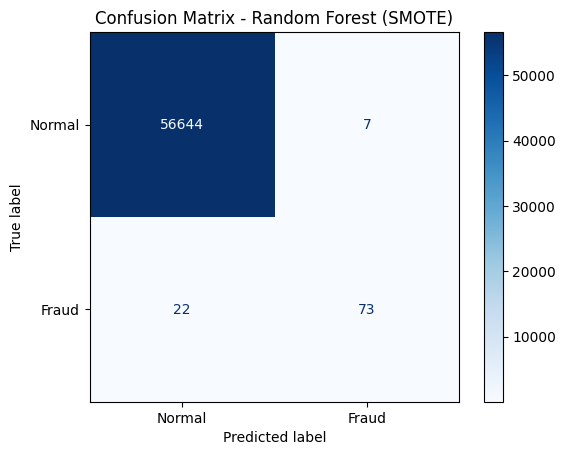

In [39]:
best_model = RandomForestClassifier(random_state=42)
best_model.fit(x_res, y_res)
y_pred = best_model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.show()

Random Forest consistently performed best across all setups. The final model selected was Random Forest with SMOTE because it improved fraud recall while maintaining strong precision.

Multiple models were evaluated under original, under-sampled, and SMOTE-balanced settings. Random Forest consistently delivered the strongest fraud detection performance. The final model selected was Random Forest with SMOTE, as it improved fraud recall while maintaining high precision and a very low false-positive rate.

Model Deployment

In [40]:
rfc = RandomForestClassifier()
rfc.fit(x_res, y_res)
joblib.dump(rfc, "credit_card_model.pkl")
model = joblib.load("credit_card_model.pkl")

In [41]:
pred = model.predict([[12,1.10321543528383,-0.0402962145973447,1.2673320885949,1.28909146962552,-0.735997163604068,0.288069162976262,-0.586056786337461,0.189379713679593,0.782332891785191,-0.267975066537173,-0.450311279515466,0.936707714991982,0.708380406186981,-0.468647287707221,0.354574063407955,-0.246634655717582,-0.00921237772707382,-0.595912405700819,-0.57568162226261,-0.113910176982092,-0.0246120063374677,0.196001952806192,0.0138016541409422,0.103758331023198,0.364297540595235,-0.382260574113217,0.092809187460487,0.0370505169810008,12.99]])

C:\Users\Pramita Mondal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [42]:
if pred[0] == 0:
    print("Normal Transaction")
else:
    print("Fraud Transaction")

Normal Transaction
